# Reinforcement Learning
Core RL concepts with pure Python/NumPy implementations.
Prerequisites: `pip install numpy matplotlib`

📺 **Video Lecture:** [https://youtu.be/0d70e5V333A](https://youtu.be/0d70e5V333A)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. The RL Framework
Agent interacts with environment: **State → Action → Reward → Next State**

In [3]:
# Simple GridWorld environment
class GridWorld:
    """4x4 grid. Agent starts at (0,0), goal at (3,3). -1 per step, +10 at goal."""
    def __init__(self, size=4):
        self.size = size
        self.state = (0, 0)
        self.goal = (size-1, size-1)
        self.actions = ['up', 'down', 'left', 'right']
    
    def reset(self):
        self.state = (0, 0)
        return self.state
    
    def step(self, action):
        r, c = self.state
        if action == 'up':    r = max(0, r-1)
        elif action == 'down':  r = min(self.size-1, r+1)
        elif action == 'left':  c = max(0, c-1)
        elif action == 'right': c = min(self.size-1, c+1)
        self.state = (r, c)
        done = self.state == self.goal
        reward = 10.0 if done else -1.0
        return self.state, reward, done

env = GridWorld()
state = env.reset()
total_reward = 0
for action in ['right', 'right', 'down', 'down', 'down', 'right']:
    state, reward, done = env.step(action)
    total_reward += reward
    print(f'Action: {action:5s} → State: {state}, Reward: {reward:+.0f}, Done: {done}')
print(f'Total reward: {total_reward}')

Action: right → State: (0, 1), Reward: -1, Done: False
Action: right → State: (0, 2), Reward: -1, Done: False
Action: down  → State: (1, 2), Reward: -1, Done: False
Action: down  → State: (2, 2), Reward: -1, Done: False
Action: down  → State: (3, 2), Reward: -1, Done: False
Action: right → State: (3, 3), Reward: +10, Done: True
Total reward: 5.0


## 2. Q-Learning
Off-policy TD control: Q(s,a) ← Q(s,a) + α[r + γ max Q(s',a') - Q(s,a)]

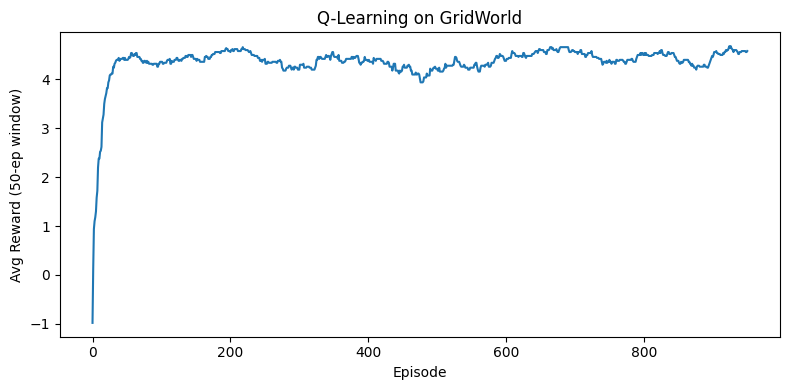

In [4]:
def q_learning(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = np.zeros((env.size, env.size, len(env.actions)))
    action_map = {a: i for i, a in enumerate(env.actions)}
    rewards_per_episode = []
    
    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        
        for _ in range(100):  # max steps
            r, c = state
            # Epsilon-greedy action selection
            if np.random.random() < epsilon:
                action_idx = np.random.randint(len(env.actions))
            else:
                action_idx = np.argmax(Q[r, c])
            
            action = env.actions[action_idx]
            next_state, reward, done = env.step(action)
            nr, nc = next_state
            
            # Q-learning update
            Q[r, c, action_idx] += alpha * (
                reward + gamma * np.max(Q[nr, nc]) - Q[r, c, action_idx]
            )
            
            total_reward += reward
            state = next_state
            if done:
                break
        
        rewards_per_episode.append(total_reward)
    
    return Q, rewards_per_episode

env = GridWorld()
Q, rewards = q_learning(env, episodes=1000)

# Plot learning curve
fig, ax = plt.subplots(figsize=(8, 4))
window = 50
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
ax.plot(smoothed)
ax.set_xlabel('Episode'); ax.set_ylabel('Avg Reward (50-ep window)')
ax.set_title('Q-Learning on GridWorld'); plt.tight_layout(); plt.show()

## 3. Visualizing the Learned Policy

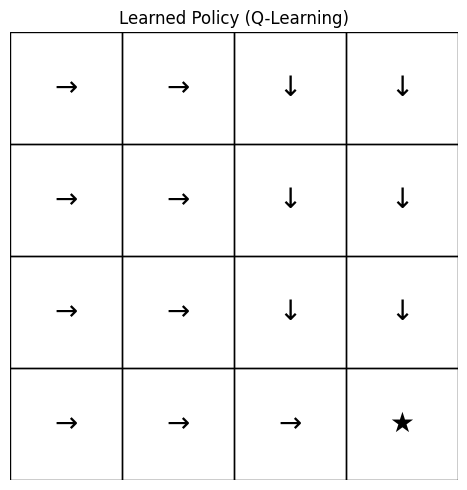

In [5]:
# Show the optimal policy as arrows
arrow_map = {0: '↑', 1: '↓', 2: '←', 3: '→'}
fig, ax = plt.subplots(figsize=(5, 5))
for r in range(4):
    for c in range(4):
        best_action = np.argmax(Q[r, c])
        symbol = '★' if (r, c) == (3, 3) else arrow_map[best_action]
        ax.text(c, 3-r, symbol, ha='center', va='center', fontsize=20)
        ax.add_patch(plt.Rectangle((c-0.5, 3-r-0.5), 1, 1, fill=False, edgecolor='black'))
ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.5, 3.5)
ax.set_title('Learned Policy (Q-Learning)'); ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Multi-Armed Bandit
The exploration-exploitation tradeoff in its simplest form.

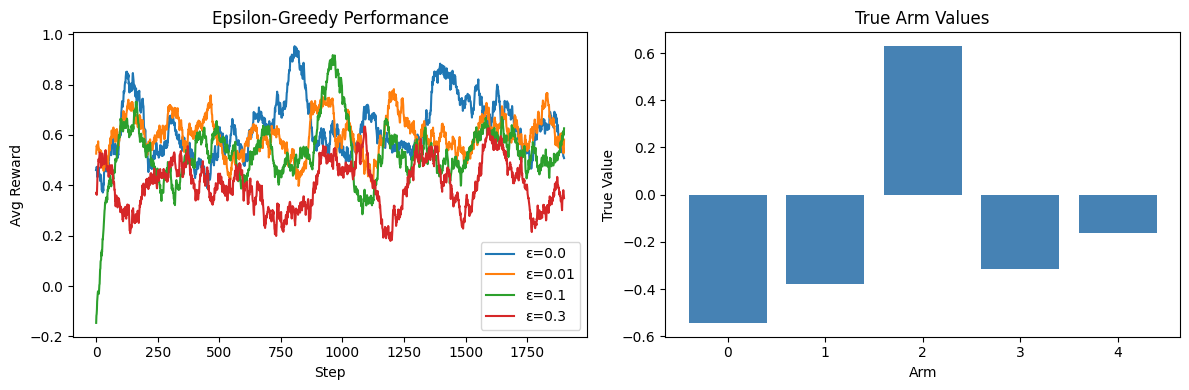

In [6]:
class MultiarmedBandit:
    def __init__(self, n_arms=5):
        self.true_values = np.random.randn(n_arms)
    
    def pull(self, arm):
        return np.random.randn() + self.true_values[arm]

def epsilon_greedy_bandit(bandit, n_steps=2000, epsilon=0.1):
    n_arms = len(bandit.true_values)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []
    
    for t in range(n_steps):
        if np.random.random() < epsilon:
            arm = np.random.randint(n_arms)
        else:
            arm = np.argmax(Q)
        
        reward = bandit.pull(arm)
        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]  # incremental mean
        rewards.append(reward)
    
    return rewards, Q

bandit = MultiarmedBandit(n_arms=5)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for eps in [0.0, 0.01, 0.1, 0.3]:
    rewards, _ = epsilon_greedy_bandit(bandit, epsilon=eps)
    smoothed = np.convolve(rewards, np.ones(100)/100, mode='valid')
    axes[0].plot(smoothed, label=f'ε={eps}')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Avg Reward')
axes[0].set_title('Epsilon-Greedy Performance'); axes[0].legend()

axes[1].bar(range(5), bandit.true_values, color='steelblue')
axes[1].set_xlabel('Arm'); axes[1].set_ylabel('True Value')
axes[1].set_title('True Arm Values')
plt.tight_layout(); plt.show()

## 5. Policy Gradient (REINFORCE) Concept

Final policy: P(action=0)=0.085, P(action=1)=0.915
Average reward (last 100): 0.650


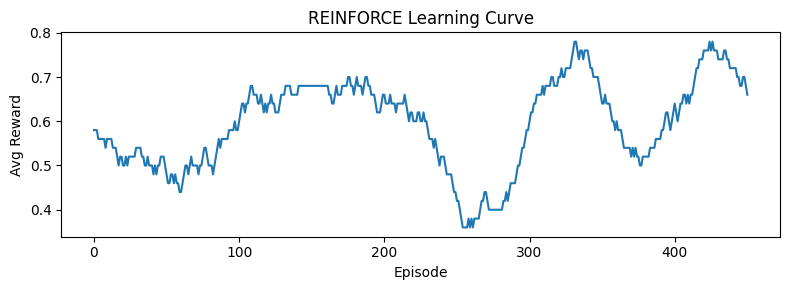

In [7]:
# Simplified REINFORCE on a 2-action problem
def softmax(logits):
    e = np.exp(logits - np.max(logits))
    return e / e.sum()

# 2-action problem: action 1 gives reward +1 with prob 0.7, action 0 gives +1 with prob 0.3
theta = np.zeros(2)  # policy parameters
alpha = 0.05
reward_history = []

for episode in range(500):
    probs = softmax(theta)
    action = np.random.choice(2, p=probs)
    reward = 1.0 if np.random.random() < (0.7 if action == 1 else 0.3) else 0.0
    
    # REINFORCE update: θ += α * R * ∇log π(a|s)
    grad = -probs.copy()
    grad[action] += 1  # one-hot minus probs
    theta += alpha * reward * grad
    reward_history.append(reward)

print(f'Final policy: P(action=0)={softmax(theta)[0]:.3f}, P(action=1)={softmax(theta)[1]:.3f}')
print(f'Average reward (last 100): {np.mean(reward_history[-100:]):.3f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.convolve(reward_history, np.ones(50)/50, mode='valid'))
ax.set_xlabel('Episode'); ax.set_ylabel('Avg Reward')
ax.set_title('REINFORCE Learning Curve'); plt.tight_layout(); plt.show()

## 6. Interview Takeaways
- **RL framework**: Agent, Environment, State, Action, Reward, Policy
- **Value-based** (Q-learning, DQN) vs **Policy-based** (REINFORCE, PPO)
- **Exploration vs Exploitation**: ε-greedy, UCB, Thompson sampling
- **Q-learning**: off-policy, uses max Q for updates
- **SARSA**: on-policy, uses actual next action for updates
- **Policy gradient**: directly optimize the policy parameterization
- Modern RL: PPO, SAC, RLHF (used to align LLMs)

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>